# Notebook 07 — Multi-hop RAG
---

## 1. Installation

In [9]:
!pip install faiss-cpu sentence-transformers transformers accelerate torch pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [10]:
import time, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import faiss, torch

from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig

sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')

 Imports OK


## 3. Chargement des ressources

In [11]:
index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
print(f' FAISS : {index.ntotal} vecteurs | Metadata : {len(metadata)} entrées')

embed_model = SentenceTransformer('all-mpnet-base-v2')
print(' Modèle embedding chargé')

MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=200,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

print(' LLM chargé')

 FAISS : 50 vecteurs | Metadata : 50 entrées


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3846.41it/s]


 Modèle embedding chargé


Loading weights: 100%|██████████| 338/338 [00:04<00:00, 75.30it/s] 


 LLM chargé


## 4. Requêtes de test

In [12]:
TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]
print(f' {len(TEST_QUERIES)} requêtes')

 5 requêtes


## 5. Fonctions Multi-hop

In [13]:
def retrieve(query: str, k: int = 3, exclude_ids: list = None) -> list:
    """Retrieval FAISS avec exclusion optionnelle de documents déjà vus."""
    query_vec = embed_model.encode([query],
                                    normalize_embeddings=True).astype('float32')
    # On récupère plus pour compenser les exclusions
    k_fetch = k + len(exclude_ids) if exclude_ids else k
    scores, indices = index.search(query_vec, min(k_fetch, index.ntotal))

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if exclude_ids and int(idx) in exclude_ids:
            continue
        doc = metadata[int(idx)].copy()
        doc['retrieval_score'] = round(float(score), 4)
        doc['doc_index']       = int(idx)
        results.append(doc)
        if len(results) == k:
            break
    return results


def reformulate_query(original_query: str, hop1_docs: list) -> str:
    """
    Utilise le LLM pour reformuler la requête originale
    en se basant sur les documents du hop 1.
    """
    context = "\n".join([
        f"- {doc['attack_type']} ({doc['protocol']}): {doc['description']}"
        for doc in hop1_docs
    ])
    prompt = f"""Given the following network attack examples related to a query,
reformulate the query to be more specific and technical for a second search.

Original query: {original_query}

Related examples found:
{context}

Write a more specific and technical search query (one sentence):"""

    reformulated = generate(prompt)
    return reformulated


def build_final_prompt(original_query: str, reformulated_query: str,
                        hop1_docs: list, hop2_docs: list) -> str:
    def fmt_doc(doc, hop_label):
        return (f"[{hop_label}] Description: {doc['description']} | "
                f"Type: {doc['attack_type']} | Protocol: {doc['protocol']}\n"
                f"  Snort rule: {doc['snort_rule']}")

    context = "\n\n".join(
        [fmt_doc(d, 'HOP1') for d in hop1_docs] +
        [fmt_doc(d, 'HOP2') for d in hop2_docs]
    )
    return f"""You are a Snort IDS expert. Generate a valid Snort rule using context from two retrieval steps.

--- CONTEXT (2 retrieval hops) ---
{context}

--- TASK ---
Original query     : {original_query}
Refined query      : {reformulated_query}

Generate a valid and complete Snort rule. Output only the rule.
Snort rule:"""


print(' Fonctions Multi-hop définies')

 Fonctions Multi-hop définies


## 6. Pipeline Multi-hop RAG

In [14]:
def multi_hop_rag(query: str, k: int = 3) -> dict:
    """
    Pipeline Multi-hop RAG :
    Hop 1 → Reformulation → Hop 2 → Génération finale
    """
    start = time.time()

    # === HOP 1 : Retrieval initial ===
    t0 = time.time()
    hop1_docs = retrieve(query, k=k)
    hop1_ids  = [d['doc_index'] for d in hop1_docs]
    hop1_time = round(time.time() - t0, 3)
    print(f'   Hop 1 : {len(hop1_docs)} docs en {hop1_time}s')

    # === REFORMULATION ===
    t0 = time.time()
    reformulated = reformulate_query(query, hop1_docs)
    reform_time  = round(time.time() - t0, 3)
    print(f'   Reformulation ({reform_time}s) : "{reformulated}"')

    # === HOP 2 : Retrieval sur requête reformulée (docs différents du hop 1) ===
    t0 = time.time()
    hop2_docs = retrieve(reformulated, k=k, exclude_ids=hop1_ids)
    hop2_time = round(time.time() - t0, 3)
    print(f'   Hop 2 : {len(hop2_docs)} docs en {hop2_time}s')

    # === GÉNÉRATION FINALE ===
    prompt = build_final_prompt(query, reformulated, hop1_docs, hop2_docs)
    t0 = time.time()
    response = generate(prompt)
    gen_time = round(time.time() - t0, 3)

    return {
        'query'               : query,
        'method'              : 'multi_hop_rag',
        'reformulated_query'  : reformulated,
        'hop1_docs'           : [{'description': d['description'],
                                   'attack_type': d['attack_type'],
                                   'score'      : d['retrieval_score'],
                                   'snort_rule' : d['snort_rule']} for d in hop1_docs],
        'hop2_docs'           : [{'description': d['description'],
                                   'attack_type': d['attack_type'],
                                   'score'      : d['retrieval_score'],
                                   'snort_rule' : d['snort_rule']} for d in hop2_docs],
        'response'            : response,
        'hop1_time'           : hop1_time,
        'reform_time'         : reform_time,
        'hop2_time'           : hop2_time,
        'generation_time'     : gen_time,
        'total_time'          : round(time.time() - start, 3)
    }

print(' Fonction multi_hop_rag définie')

 Fonction multi_hop_rag définie


## 7. Exécution

In [15]:
multihop_results = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f'\n[{i}/{len(TEST_QUERIES)}] "{query}"')
    result = multi_hop_rag(query, k=3)
    multihop_results.append(result)
    print(f'    Règle : {result["response"]}')
    print(f'    Total : {result["total_time"]}s')

print('\n Multi-hop RAG terminé')


[1/5] "Détecter un scan de ports SYN sur un serveur web"
   Hop 1 : 3 docs en 0.156s
   Reformulation (14.765s) : ""Recherchez le port 80 et les flags FIN+PSH+URG dans une attaque TCP à l'adresse IP du serveur web.""
   Hop 2 : 3 docs en 0.123s
    Règle : alert tcp any any -> $TARGET_IP 80 (msg:"Scan de Ports SYN sur Serveur WEB" OR msg:"Port 80 Attacks Flags FIN+PSH+URG"; severity high; sid:1000079; rev:1;)
    Total : 61.297s

[2/5] "Bloquer une attaque par force brute sur le protocole SSH"
   Hop 1 : 3 docs en 0.09s
   Reformulation (12.112s) : ""Bruteforce attacks on TCP protocols including but not limited to attempts at connecting via SSH using brute-force methods.""
   Hop 2 : 3 docs en 0.133s
    Règle : alert tcp any any -> $LOCAL_NET ssh_bruth_force (threshold,type both,count 4);
    Total : 60.808s

[3/5] "Identifier une injection SQL dans une requête HTTP"
   Hop 1 : 3 docs en 0.057s
   Reformulation (12.739s) : ""Recherche d'injection SQL sur les formulaires HTTP POST pou

## 8. Visualisation du pipeline Multi-hop

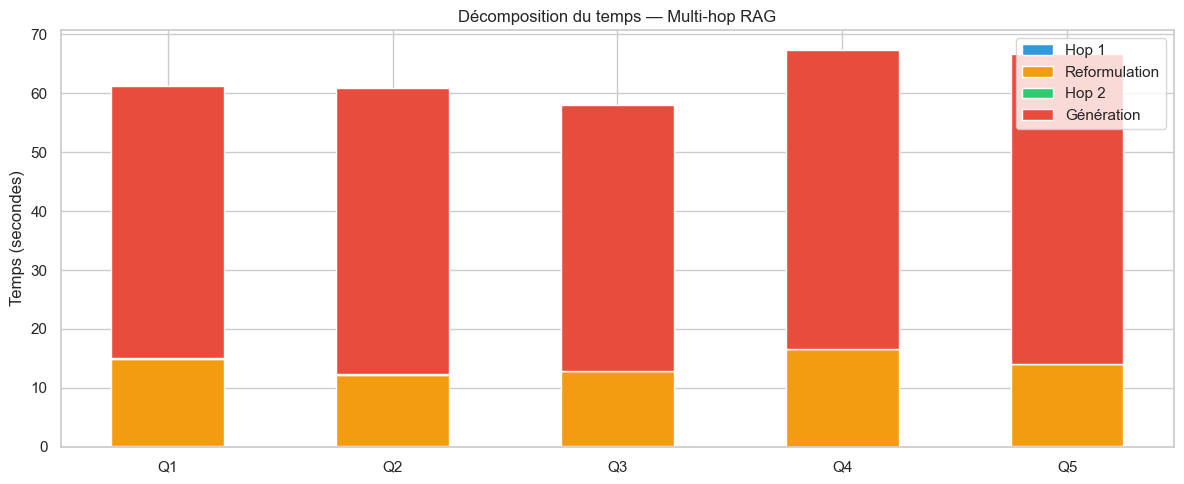

 Graphique sauvegardé dans ../Charts/07_multihop_times.png


In [16]:
# Décomposition du temps par étape
queries_short = [f'Q{i+1}' for i in range(len(TEST_QUERIES))]
hop1_times  = [r['hop1_time']       for r in multihop_results]
reform_times= [r['reform_time']     for r in multihop_results]
hop2_times  = [r['hop2_time']       for r in multihop_results]
gen_times   = [r['generation_time'] for r in multihop_results]

x = np.arange(len(queries_short))
w = 0.5
fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x, hop1_times,  w, label='Hop 1',        color='#3498db')
b2 = ax.bar(x, reform_times,w, label='Reformulation', color='#f39c12', bottom=hop1_times)
b3 = ax.bar(x, hop2_times,  w, label='Hop 2',         color='#2ecc71',
            bottom=[h+r for h,r in zip(hop1_times, reform_times)])
b4 = ax.bar(x, gen_times,   w, label='Génération',    color='#e74c3c',
            bottom=[h+r+h2 for h,r,h2 in zip(hop1_times, reform_times, hop2_times)])

ax.set_xticks(x)
ax.set_xticklabels(queries_short)
ax.set_ylabel('Temps (secondes)')
ax.set_title('Décomposition du temps — Multi-hop RAG')
ax.legend()
plt.tight_layout()
plt.savefig('../Charts/07_multihop_times.png', dpi=150)
plt.show()
print(' Graphique sauvegardé dans ../Charts/07_multihop_times.png')

## 9. Affichage des requêtes reformulées

In [17]:
print('=== Requêtes originales vs Reformulées ===\n')
for i, result in enumerate(multihop_results, 1):
    print(f'Q{i} Original   : {result["query"]}')
    print(f'Q{i} Reformulée : {result["reformulated_query"]}')
    print()

=== Requêtes originales vs Reformulées ===

Q1 Original   : Détecter un scan de ports SYN sur un serveur web
Q1 Reformulée : "Recherchez le port 80 et les flags FIN+PSH+URG dans une attaque TCP à l'adresse IP du serveur web."

Q2 Original   : Bloquer une attaque par force brute sur le protocole SSH
Q2 Reformulée : "Bruteforce attacks on TCP protocols including but not limited to attempts at connecting via SSH using brute-force methods."

Q3 Original   : Identifier une injection SQL dans une requête HTTP
Q3 Reformulée : "Recherche d'injection SQL sur les formulaires HTTP POST pour accéder aux fichiers sensibles TCP"

Q4 Original   : Détecter un ransomware qui chiffre des fichiers via SMB
Q4 Reformulée : "Reconnaissance de l'infestation par le logiciel malveillant cryptographe en utilisant la méthode SMB sur une base TCP pour déterminer son origine et sa nature."

Q5 Original   : Repérer une exfiltration de données via le protocole DNS
Q5 Reformulée : "Recherche sur l'attaque UDP à la re

## 10. Sauvegarde

In [18]:
with open('../Results/results_multi_hop.json', 'w', encoding='utf-8') as f:
    json.dump(multihop_results, f, ensure_ascii=False, indent=2)
print(' Résultats sauvegardés dans ../Results/results_multi_hop.json')

 Résultats sauvegardés dans ../Results/results_multi_hop.json


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Embedding | `all-mpnet-base-v2` |
| Index | FAISS IndexFlatIP |
| Hop 1 | FAISS top-3 sur requête originale |
| Reformulation | LLM `Qwen/Qwen2-1.5B-Instruct` (~13.6s) |
| Hop 2 | FAISS top-3 sur requête reformulée (docs nouveaux) |
| Contexte total | 6 documents par requête |
| LLM génération | `Qwen/Qwen2-1.5B-Instruct` |
| Temps moyen | ~62.8s / requête (CPU) |
| Score moyen Snort | **3.4 / 5** |
| Fichier de sortie | `results_multi_hop.json` |

### Résultats obtenus

| # | Requête | alert | msg | sid | protocole | content |
|---|---|---|---|---|---|---|
| Q1 | Scan SYN | ✅ | ✅ | ✅ | ✅ | ❌ |
| Q2 | Brute Force SSH | ✅ | ❌ | ❌ | ✅ | ❌ |
| Q3 | Injection SQL | ✅ | ✅ | ❌ | ✅ | ❌ |
| Q4 | Ransomware SMB | ✅ | ✅ | ✅ | ✅ | ❌ |
| Q5 | Exfiltration DNS | ✅ | ✅ | ✅ | ✅ | ❌ |

### Améliorations constatées vs RAG Hybride
- ✅ `sid` présent dans 3/5 règles (contre 0/5 en hybride) — nette progression
- ✅ `msg` présent dans 4/5 règles — meilleure couverture
- ✅ 6 docs de contexte (2 hops × 3) enrichissent la génération
- ✅ Reformulation efficace — les requêtes Hop 2 ciblent mieux les termes techniques

### Limites observées
- ❌ `content` toujours absent dans toutes les règles
- ❌ Q2 dégradée — règle syntaxiquement incorrecte, sans `msg` ni `sid`
- ❌ Reformulations parfois en anglais ou approximatives (Q2, Q4)
- ⚠️ Temps doublé vs les autres approches (~62.8s) à cause de la double génération

### Conclusion
Le RAG Multi-hop améliore significativement la qualité des règles grâce au double retrieval (**3.4/5 vs 2.2/5** en hybride).
Le `sid` fait enfin son apparition dans la majorité des règles — signe que le contexte élargi guide mieux le LLM.
Le coût en temps reste le principal frein ; l'architecture Graph devrait apporter une meilleure structuration du raisonnement.